In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [3]:
df = pd.read_parquet("../dataset/processed_dataset.parquet")

print(df.shape)

df.head(100)

(2313810, 44)


,Packet Length Variance,Bwd Packet Length Max,Packet Length Max,Fwd IAT Std,Flow IAT Max,Packet Length Mean,Fwd Packets Length Total,Fwd Packet Length Max,Init Bwd Win Bytes,Bwd Header Length,...,ACK Flag Count,FIN Flag Count,Active Max,Packet Length Min,Bwd Packet Length Min,Down/Up Ratio,Idle Std,URG Flag Count,Active Std,Label
0,0.000000,0,6,0.000000,3,6.000000,12,6,-1,0,...,1,0,0,6,0,0,0.0,0,0.0,0
1,0.000000,6,6,0.000000,109,6.000000,6,6,256,20,...,1,0,0,6,6,1,0.0,1,0.0,0
2,0.000000,6,6,0.000000,52,6.000000,6,6,256,20,...,1,0,0,6,6,1,0.0,1,0.0,0
3,0.000000,6,6,0.000000,34,6.000000,6,6,329,20,...,1,0,0,6,6,1,0.0,1,0.0,0
4,0.000000,0,6,0.000000,3,6.000000,12,6,-1,0,...,1,0,0,6,0,0,0.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2270.699951,123,123,0.000000,1124,70.800003,72,36,-1,64,...,0,0,0,36,123,1,0.0,0,0.0,0
96,4915.200195,164,164,0.000000,287,87.199997,72,36,-1,64,...,0,0,0,36,164,1,0.0,0,0.0,0
97,59217.218750,976,976,159265.328125,951360,114.500000,2664,456,243,1360,...,0,0,0,0,0,1,0.0,0,0.0,0
98,0.000000,0,0,0.000000,187,0.000000,0,0,243,32,...,1,0,0,0,0,1,0.0,1,0.0,0


In [4]:
X = df.drop("Label", axis=1)

y = df["Label"]

print(X.shape)
print(y.shape)
print(sorted(y.unique()))

(2313810, 43)
(2313810,)
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [5]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1851048, 43)
Testing Features  : (462762, 43)
Training Labels   : (1851048,)
Testing Labels    : (462762,)


In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)

/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


In [8]:

y_pred = lr.predict(X_test)


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9558


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    395464
           1       0.00      0.00      0.00       288
           2       0.84      0.91      0.87     25603
           3       0.47      0.55      0.51      2057
           4       0.92      0.79      0.85     34569
           5       0.54      0.64      0.59      1046
           6       0.31      0.21      0.25      1077
           7       0.00      0.00      0.00      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00       391
          11       0.00      0.00      0.00       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.96    462762
   macro avg       0.27      0.27      0.27    462762
weighted avg       0.95   

/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[389670      0   2349   1060   1010    538    500    117      0      0
      54     55     35      0     76]
 [   280      0      8      0      0      0      0      0      0      0
       0      0      0      0      0]
 [   891      0  23334      8   1370      0      0      0      0      0
       0      0      0      0      0]
 [   914      0      0   1130     11      1      1      0      0      0
       0      0      0      0      0]
 [  5098      0   2154     34  27264      0      0      7      0      0
       0     12      0      0      0]
 [   173      0     51    136      0    669     17      0      0      0
       0      0      0      0      0]
 [   791      0      1     34      0     20    231      0      0      0
       0      0      0      0      0]
 [  1186      0      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     2      0      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     6  

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [14]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [15]:
y_pred_dt = dt.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.998403066803238
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395464
           1       0.69      0.73      0.71       288
           2       1.00      1.00      1.00     25603
           3       0.99      1.00      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.94      0.95      0.94      1046
           6       0.99      0.99      0.99      1077
           7       0.99      1.00      1.00      1186
           8       1.00      1.00      1.00         2
           9       0.60      0.43      0.50         7
          10       0.89      0.90      0.89       391
          11       1.00      0.99      0.99       644
          12       0.75      0.72      0.74       294
          13       0.40      0.50      0.44         4
          14       0.42      0.43      0.43       130

    accuracy                           1.00    462762
   macro avg       0.84      0.84      0.84    46276

In [17]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [18]:
from lightgbm import LGBMClassifier

In [19]:
lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=100
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9235
[LightGBM] [Info] Number of data points in the train set: 1851048, number of used features: 43
[LightGBM] [Info] Start training from score -0.157154
[LightGBM] [Info] Start training from score -7.384615
[LightGBM] [Info] Start training from score -2.894513
[LightGBM] [Info] Start training from score -5.415843
[LightGBM] [Info] Start training from score -2.594248
[LightGBM] [Info] Start training from score -6.092718
[LightGBM] [Info] Start training from score -6.063033
[LightGBM] [Info] Start training from score -5.966416
[LightGBM] [Info] Start training from score -12.234038
[LightGBM] [Info] Start training from score -11.063967
[LightGBM] [Info] Start

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))

Accuracy: 0.8704993063388956
              precision    recall  f1-score   support

           0       0.97      0.91      0.94    395464
           1       0.00      0.00      0.00       288
           2       0.95      0.56      0.70     25603
           3       0.02      0.01      0.01      2057
           4       0.40      0.88      0.55     34569
           5       0.00      0.00      0.00      1046
           6       0.00      0.00      0.00      1077
           7       0.00      0.00      0.00      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00       391
          11       0.00      0.00      0.00       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.87    462762
   macro avg       0.16      0.16      0.15    4627

/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/preetamkamate/Documents/NIDS_PROJECT/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [21]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=len(y.unique()),
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method="hist",
    eval_metric="mlogloss"
)

In [24]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [25]:
y_pred_xgb = xgb.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.998759621576534
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395464
           1       0.90      0.61      0.73       288
           2       1.00      1.00      1.00     25603
           3       0.99      1.00      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.92      0.98      0.95      1046
           6       1.00      0.99      0.99      1077
           7       0.99      1.00      1.00      1186
           8       1.00      1.00      1.00         2
           9       1.00      0.71      0.83         7
          10       0.95      0.91      0.93       391
          11       1.00      0.99      1.00       644
          12       0.72      0.93      0.81       294
          13       1.00      0.25      0.40         4
          14       0.48      0.12      0.20       130

    accuracy                           1.00    462762
   macro avg       0.93      0.83      0.86    46276

In [27]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "LightGBM",
        "XGBoost"
    ],
    "Accuracy (%)": [
        95.0,
        99.8,
        87.0,
        99.8
    ]
})

comparison

,Model,Accuracy (%)
0,Logistic Regression,95.0
1,Decision Tree,99.8
2,LightGBM,87.0
3,XGBoost,99.8


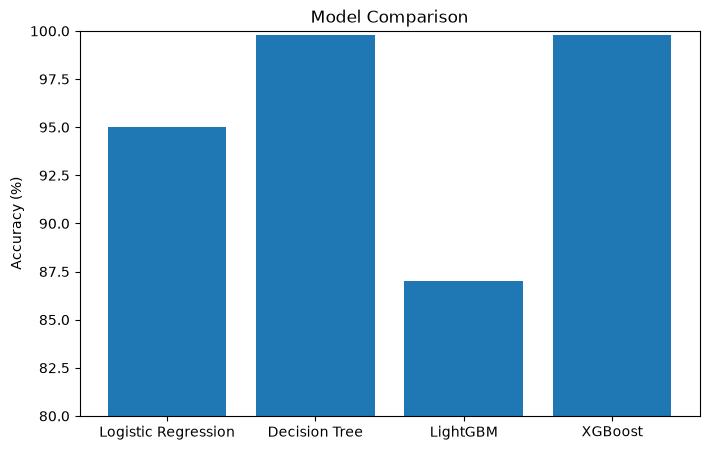

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.ylim(80,100)
plt.show()

In [29]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [34]:
import shap
explainer = shap.TreeExplainer(xgb)
X_sample = X_test.sample(100, random_state=42)

shap_values = explainer(X_sample)


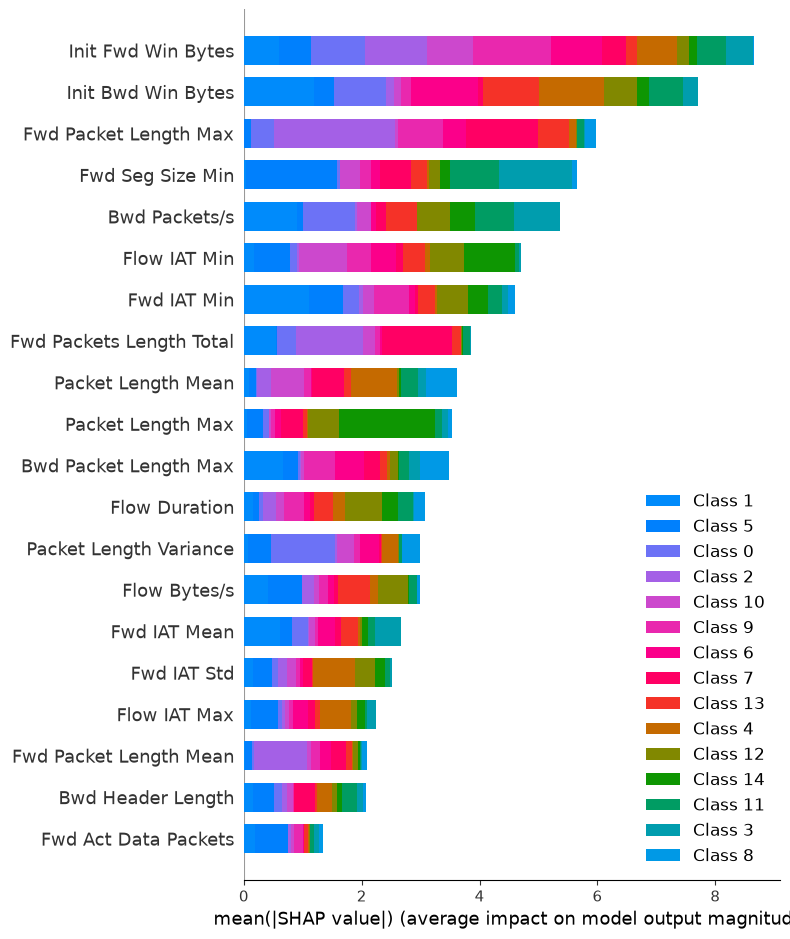

In [35]:
shap.summary_plot(shap_values, X_sample)

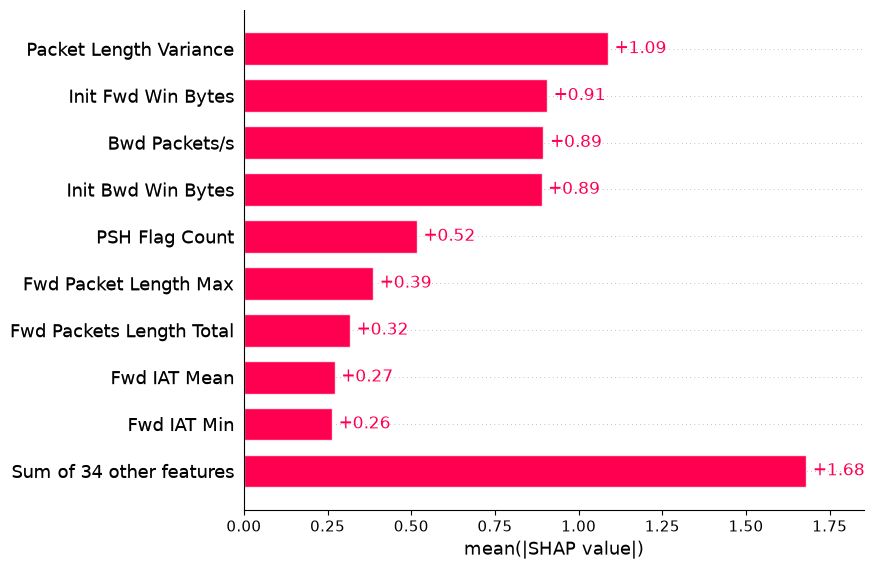

In [40]:
shap.plots.bar(shap_values[:, :, 0])

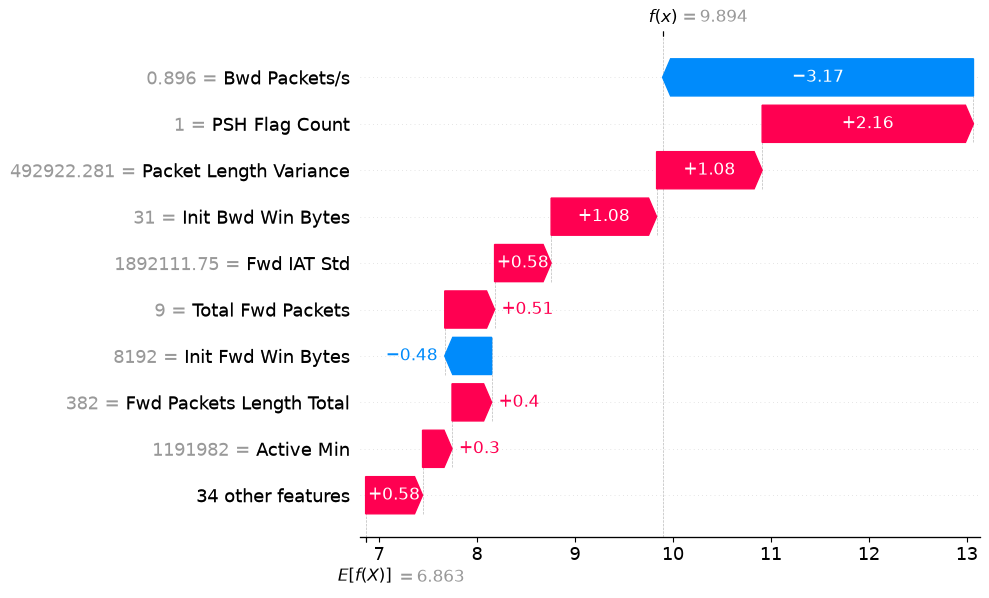

In [41]:
shap.plots.waterfall(shap_values[0, :, 0])

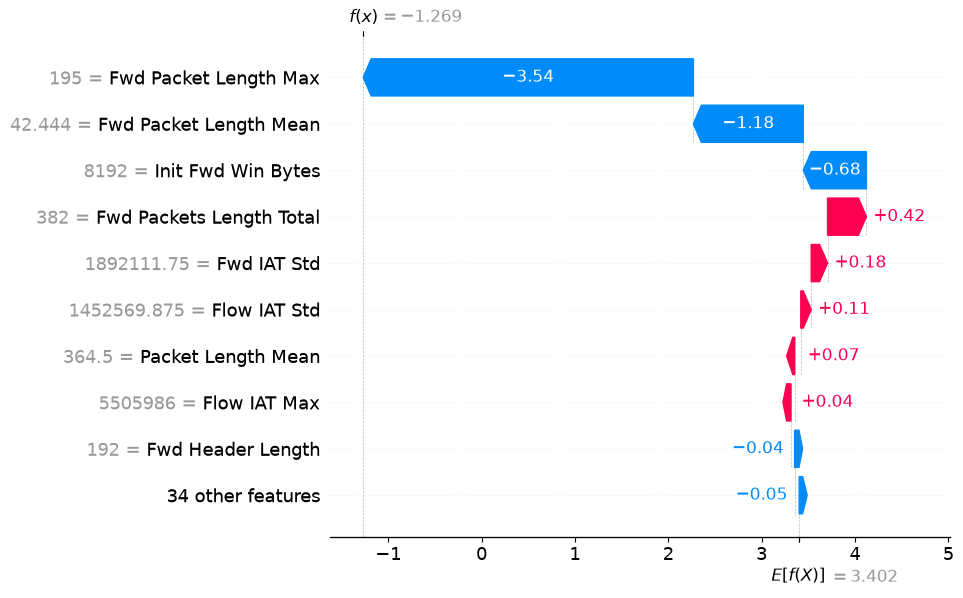

In [42]:
shap.plots.waterfall(shap_values[0, :, 2])

In [43]:
import joblib

In [44]:
joblib.dump(xgb, "../models/xgboost_nids_model.pkl")

['../models/xgboost_nids_model.pkl']

In [45]:
import os

print(os.path.exists("../models/xgboost_nids_model.pkl"))

True


In [2]:
import joblib

model = joblib.load("../models/xgboost_nids_model.pkl")

In [3]:
type(model)

xgboost.sklearn.XGBClassifier

In [7]:
print(X_train.columns.tolist())

['Packet Length Variance', 'Bwd Packet Length Max', 'Packet Length Max', 'Fwd IAT Std', 'Flow IAT Max', 'Packet Length Mean', 'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Init Bwd Win Bytes', 'Bwd Header Length', 'Flow IAT Mean', 'Fwd Packet Length Mean', 'Flow IAT Std', 'Fwd Header Length', 'Total Fwd Packets', 'Fwd Act Data Packets', 'Flow Packets/s', 'Fwd IAT Mean', 'Init Fwd Win Bytes', 'Bwd Packets/s', 'Flow Duration', 'Flow Bytes/s', 'Fwd IAT Min', 'Active Mean', 'Bwd IAT Total', 'Fwd Seg Size Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Flow IAT Min', 'Fwd Packet Length Min', 'Bwd IAT Min', 'Active Min', 'PSH Flag Count', 'Bwd IAT Mean', 'ACK Flag Count', 'FIN Flag Count', 'Active Max', 'Packet Length Min', 'Bwd Packet Length Min', 'Down/Up Ratio', 'Idle Std', 'URG Flag Count', 'Active Std']
